# Classificazione Sentenze con Anthropic API

Notebook per classificare sentenze in 5 categorie usando Claude.

Categorie:
1. **Decorrenza termini** (categoria procedurale, prioritaria)
2. **Esito a favore del lavoratore**
3. **Esito a favore del datore**
4. **Ambiguo** (non è chiaro chi vince)
5. **Non classificato** (troppo vago o non riguarda diritto del lavoro)

## Import librerie

In [55]:
import pandas as pd
from anthropic import Anthropic
import os
import time
from datetime import datetime
import json

## Configurazione API

In [ ]:
# Inizializza il client Anthropic
# Inserisci la tua API key qui

ANTHROPIC_API_KEY = "your_api_key_here"  # Sostituisci con la tua chiave API reale

client = Anthropic(api_key=ANTHROPIC_API_KEY)

## Carica il dataset

In [ ]:
# Leggi il CSV (modifica il percorso se necessario)
df = pd.read_csv("<path_to_your_csv_file>", delimiter=";") # Sostituisci con il percorso reale

df['esito2'] = df['esito2'].replace('05. DECORRENZA_TERMINI', '05. DECORRENZA TERMINI')

print(f"Dataset caricato: {len(df)} sentenze")
print(f"\nColonne: {df.columns.tolist()}")
print(f"\nPrime 3 righe:")


df.head(25)

Dataset caricato: 159 sentenze

Colonne: ['id', 'abstract', 'esito1', 'esito2']

Prime 3 righe:


,id,abstract,esito1,esito2
0,101,- Un apprendista viene addetta al reparto di i...,01. PROLAV,01. PROLAV
1,102,"Nella specie, il Tribunale, esclusi i profili ...",02. PRODAT,02. PRODAT
2,103,"Nella specie il Tribunale, confermando l ordin...",02. PRODAT,02. PRODAT
3,201,Nella specie il Tribunale ha ritenuto illegitt...,01. PROLAV,01. PROLAV
4,202,da considerarsi illegittimo il licenziamento i...,04. NON CLASS,01. PROLAV
5,203,"- Ad una lavoratrice, responsabile di un negoz...",01. PROLAV,04. NON CLASS
6,301,"Nella specie, la lavoratrice, assunta con mans...",02. PRODAT,02. PRODAT
7,302,Nella specie il Tribunale ha ritenuto nullo pe...,01. PROLAV,01. PROLAV
8,303,"Nella specie il Tribunale, confermando l ordin...",01. PROLAV,01. PROLAV
9,401,"Nella specie, confermando l ordinanza della fa...",02. PRODAT,02. PRODAT


## Definisci il prompt di classificazione

In [58]:
SYSTEM_PROMPT = """
Sei un esperto di diritto del lavoro italiano e di analisi delle sentenze.

Il tuo compito è classificare il riassunto di una sentenza italiana in UNA SOLA delle categorie indicate.

IMPORTANTE:
- Non utilizzare MAI le variabili "esito1" o "esito2" per determinare la classificazione.
- Devi basarti esclusivamente sul contenuto giuridico del riassunto.
- Devi individuare l'effettivo vincitore della controversia.
- In caso di dubbio, segui rigorosamente le regole di priorità riportate sotto.

==================================================
FASE 1 - IDENTIFICAZIONE DEL TIPO DI DECISIONE
==================================================

Prima di classificare, individua:

1. Chi ha promosso l'azione?
   - lavoratore
   - datore di lavoro
   - altro soggetto

2. Quali domande sono state formulate?

3. Quali domande sono state:
   - accolte
   - respinte
   - dichiarate inammissibili
   - improcedibili
   - assorbite

4. Chi ottiene il risultato sostanziale più favorevole?

==================================================
CATEGORIE
==================================================

01. PROLAV

Classifica come PROLAV quando emerge chiaramente che il lavoratore ottiene tutela.

Esempi:

- accoglimento del ricorso del lavoratore
- riconoscimento di differenze retributive
- riconoscimento straordinari
- riconoscimento qualifica superiore
- reintegrazione
- illegittimità del licenziamento
- conversione contratto a termine
- riconoscimento subordinazione
- risarcimento a favore del lavoratore
- annullamento di sanzioni disciplinari
- condanna del datore al pagamento di somme

Indicatori linguistici:

"accoglie il ricorso"
"condanna la società"
"riconosce il diritto"
"accerta la subordinazione"
"dichiara illegittimo il licenziamento"
"ordina la reintegrazione"

==================================================

02. PRODAT

Classifica come PRODAT quando il lavoratore perde sostanzialmente la causa oppure quando vengono accolte le domande del datore.

Esempi:

- rigetto del ricorso del lavoratore
- licenziamento ritenuto legittimo
- insussistenza delle pretese retributive
- rigetto della domanda di reintegra
- conferma della sanzione disciplinare
- accoglimento delle domande del datore

Indicatori linguistici:

"rigetta il ricorso"
"respinge la domanda"
"ritiene legittimo il licenziamento"
"esclude il diritto"
"respinge le pretese"
"rigetta integralmente"

==================================================

03. AMBIGUO

Classifica come AMBIGUO quando non esiste un vincitore chiaramente identificabile.

Esempi:

- accoglimento solo parziale
- alcune domande accolte e altre respinte
- reciproca soccombenza
- importi riconosciuti molto inferiori alle richieste
- esito misto tra lavoratore e datore
- il riassunto non permette di capire quale parte abbia ottenuto il risultato prevalente

Indicatori linguistici:

"accoglie parzialmente"
"parziale riforma"
"accoglimento limitato"
"reciproca soccombenza"
"in parte accoglie e in parte rigetta"

ATTENZIONE:
Se il lavoratore ottiene comunque il riconoscimento del diritto principale richiesto, classificare come PROLAV e NON come AMBIGUO.

==================================================

04. NON CLASS

Classifica come NON CLASS quando:

- il testo è troppo generico
- manca completamente l'esito
- la materia non è diritto del lavoro
- il riassunto descrive solo fatti o questioni procedurali
- si parla esclusivamente di competenza territoriale
- si parla esclusivamente di giurisdizione
- si parla esclusivamente di rinvio
- si parla esclusivamente di ammissibilità senza indicazione del vincitore

Esempi:

"la Corte si pronuncia sulla competenza"
"la causa viene rinviata"
"questione processuale"
"controversia previdenziale non riconducibile al rapporto di lavoro"

==================================================

05. DECORRENZA TERMINI

Classifica sempre come DECORRENZA TERMINI quando il riassunto menziona:

- decadenza
- prescrizione
- tardività del ricorso
- mancata impugnazione
- passaggio in giudicato
- decorso dei termini
- impugnazione tardiva
- termine decadenziale
- improcedibilità dovuta a termini processuali

Indicatori linguistici:

"domanda prescritta"
"azione decaduta"
"ricorso tardivo"
"impugnazione tardiva"
"mancata impugnazione"
"passata in giudicato"
"decorrenza dei termini"

05. DECORRENZA TERMINI

==================================================
CASI PARTICOLARI
==================================================

A) CASSAZIONE

Se la Cassazione:
- conferma una decisione favorevole al lavoratore → PROLAV
- conferma una decisione favorevole al datore → PRODAT
- cassa con rinvio senza indicare il vincitore → NON CLASS

B) APPELLO

Valuta SEMPRE l'esito finale dell'appello,
non quello del primo grado.

C) ACCOGLIMENTO PARZIALE

Se non è possibile identificare chiaramente un vincitore:
→ AMBIGUO

D) PLURALITÀ DI DOMANDE

Valuta quale domanda è centrale nella controversia.

Se il diritto principale del lavoratore viene riconosciuto:
→ PROLAV

Se la domanda principale viene respinta:
→ PRODAT

==================================================
PROCEDURA OBBLIGATORIA
==================================================

1. Individua il soggetto che agisce.
2. Individua la domanda principale.
3. Individua l'esito della domanda principale.
4. Verifica se ricorrono i casi di DECORRENZA TERMINI.
5. Applica la categoria corretta.

==================================================
OUTPUT
==================================================

==================================================
OUTPUT OBBLIGATORIO
==================================================

Rispondi ESCLUSIVAMENTE con un JSON valido.

Formato:

{
  "categoria": "01. PROLAV"
}

Valori consentiti:

01. PROLAV
02. PRODAT
03. AMBIGUO
04. NON CLASS
05. DECORRENZA TERMINI

Non aggiungere spiegazioni.
Non aggiungere motivazioni.
Non aggiungere testo prima o dopo il JSON.
Non usare markdown.
"""

print("✓ Prompt definito")

✓ Prompt definito


## Funzione di classificazione

In [59]:
import json
import time

def classificazione_sentenza(abstract, retry=3):
    """
    Classifica una singola sentenza usando Anthropic API.

    Returns
    -------
    categoria : str
        Codice della categoria
    success : bool
    """

    categorie_valide = {
        "01. PROLAV",
        "02. PRODAT",
        "03. AMBIGUO",
        "04. NON CLASS",
        "05. DECORRENZA TERMINI"
    }

    for tentativo in range(retry):

        try:

            message = client.messages.create(
                model="claude-sonnet-4-6",
                max_tokens=20,
                temperature=0,
                system=SYSTEM_PROMPT,
                messages=[
                    {
                        "role": "user",
                        "content": (
                            "Classifica il seguente riassunto "
                            "e restituisci esclusivamente il JSON richiesto.\n\n"
                            f"{abstract}"
                        )
                    }
                ]
            )

            risposta = message.content[0].text.strip()

            try:

                risultato = json.loads(risposta)

                categoria = risultato.get("categoria", "").strip()

                if categoria in categorie_valide:
                    return categoria, True

                print(
                    f"⚠️ Categoria non valida restituita: "
                    f"{categoria}"
                )

                return "04. NON CLASS", False

            except json.JSONDecodeError:

                print(
                    f"⚠️ JSON non valido restituito:\n{risposta}"
                )

                return "04. NON CLASS", False

        except Exception as e:

            if tentativo < retry - 1:

                wait_time = 2 ** tentativo

                print(
                    f"Errore (tentativo {tentativo + 1}/{retry}): "
                    f"{e}. Riprovo tra {wait_time}s..."
                )

                time.sleep(wait_time)

            else:

                print(
                    f"❌ Errore dopo {retry} tentativi: {e}"
                )

                return "04. NON CLASS", False

    return "04. NON CLASS", False


print("✓ Funzione di classificazione definita")

✓ Funzione di classificazione definita


## Classifica tutte le sentenze

In [60]:
# Inizializza colonna per le classificazioni LLM
df['esito_llm'] = None
df['classificazione_riuscita'] = False

print(f"Inizio classificazione di {len(df)} sentenze...\n")
print(f"Orario inizio: {datetime.now().strftime('%H:%M:%S')}")
print("-" * 60)

# Classifica ogni sentenza
for idx, row in df.iterrows():
    if idx % 10 == 0:
        print(f"\nProgresso: {idx + 1}/{len(df)} ({100 * (idx + 1) / len(df):.1f}%)")
    
    abstract = row['abstract']
    categoria, successo = classificazione_sentenza(abstract)
    
    df.at[idx, 'esito_llm'] = categoria
    df.at[idx, 'classificazione_riuscita'] = successo
    
    # Rate limiting: pausa breve tra richieste
    if (idx + 1) % 10 == 0:
        time.sleep(0.5)

print("\n" + "-" * 60)
print(f"Orario fine: {datetime.now().strftime('%H:%M:%S')}")
print(f"Classificazione completata: {df['classificazione_riuscita'].sum()}/{len(df)} riuscite")

Inizio classificazione di 159 sentenze...

Orario inizio: 15:34:11
------------------------------------------------------------

Progresso: 1/159 (0.6%)

Progresso: 11/159 (6.9%)

Progresso: 21/159 (13.2%)
⚠️ JSON non valido restituito:
```json
{"categoria": "02. PRODAT"}
```

Progresso: 31/159 (19.5%)

Progresso: 41/159 (25.8%)

Progresso: 51/159 (32.1%)

Progresso: 61/159 (38.4%)

Progresso: 71/159 (44.7%)

Progresso: 81/159 (50.9%)

Progresso: 91/159 (57.2%)

Progresso: 101/159 (63.5%)

Progresso: 111/159 (69.8%)

Progresso: 121/159 (76.1%)

Progresso: 131/159 (82.4%)

Progresso: 141/159 (88.7%)

Progresso: 151/159 (95.0%)

------------------------------------------------------------
Orario fine: 15:43:42
Classificazione completata: 158/159 riuscite


## Analisi risultati

In [61]:
print("\n📊 DISTRIBUZIONE CLASSIFICAZIONI LLM:")
print("="*60)
distribuzione_llm = df['esito_llm'].value_counts()
for categoria, count in distribuzione_llm.items():
    percentuale = 100 * count / len(df)
    print(f"{categoria:.<40} {count:>3} ({percentuale:>5.1f}%)")

print("\n📊 DISTRIBUZIONE ESITO1 (Modello precedente):")
print("="*60)
distribuzione_esito1 = df['esito1'].value_counts()
for categoria, count in distribuzione_esito1.items():
    percentuale = 100 * count / len(df)
    print(f"{str(categoria):.<40} {count:>3} ({percentuale:>5.1f}%)")

print("\n📊 DISTRIBUZIONE ESITO2 (Modello precedente):")
print("="*60)
distribuzione_esito2 = df['esito2'].value_counts()
for categoria, count in distribuzione_esito2.items():
    percentuale = 100 * count / len(df)
    print(f"{str(categoria):.<40} {count:>3} ({percentuale:>5.1f}%)")


📊 DISTRIBUZIONE CLASSIFICAZIONI LLM:
01. PROLAV..............................  76 ( 47.8%)
02. PRODAT..............................  70 ( 44.0%)
03. AMBIGUO.............................   8 (  5.0%)
05. DECORRENZA TERMINI..................   4 (  2.5%)
04. NON CLASS...........................   1 (  0.6%)

📊 DISTRIBUZIONE ESITO1 (Modello precedente):
01. PROLAV..............................  81 ( 50.9%)
02. PRODAT..............................  55 ( 34.6%)
03. AMBIGUO.............................  14 (  8.8%)
04. NON CLASS...........................   5 (  3.1%)
05. DECORRENZA TERMINI..................   4 (  2.5%)

📊 DISTRIBUZIONE ESITO2 (Modello precedente):
02. PRODAT..............................  72 ( 45.3%)
01. PROLAV..............................  52 ( 32.7%)
04. NON CLASS...........................  22 ( 13.8%)
03. AMBIGUO.............................  10 (  6.3%)
05. DECORRENZA TERMINI..................   3 (  1.9%)


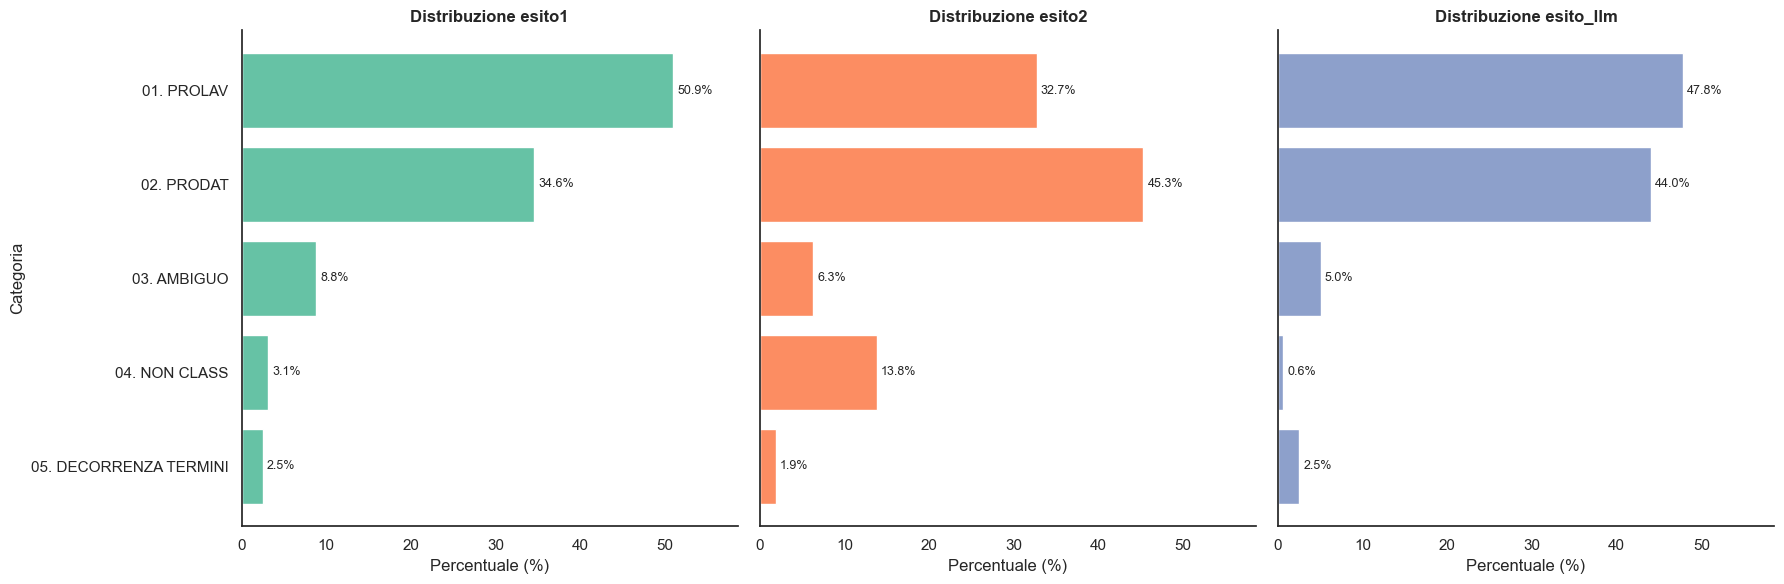

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="white")

colonne = ['esito1', 'esito2', 'esito_llm']
palette = sns.color_palette("Set2", 3)

# Compute global max once (for consistent axis)
max_val = max(
    df[col].value_counts(normalize=True).mul(100).max()
    for col in colonne
)
x_limit = max_val * 1.15

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, col, color in zip(axes, colonne, palette):
    
    dist = df[col].value_counts(normalize=True).mul(100).sort_values()

    # Plot
    bars = ax.barh(dist.index, dist.values, color=color)

    # ✅ Correct label placement (use bar geometry, not enumerate)
    for bar in bars:
        width = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2
        ax.text(width + 0.5, y, f"{width:.1f}%", va='center', fontsize=9)

    ax.set_title(f'Distribuzione {col}', fontweight='bold')
    ax.set_xlabel('Percentuale (%)')
    ax.set_xlim(0, x_limit)

    if ax is axes[0]:
        ax.set_ylabel('Categoria')
    else:
        ax.set_ylabel('')

    ax.grid(False)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Confronto tra i tre modelli

In [64]:
# Crea una matrice di confronto
print("\n🔄 CONCORDANZA TRA MODELLI:")
print("="*60)

# LLM vs ESITO1
concordanza_llm_e1 = (df['esito_llm'] == df['esito1']).sum()
percentuale_llm_e1 = 100 * concordanza_llm_e1 / len(df)
print(f"LLM vs ESITO1: {concordanza_llm_e1}/{len(df)} ({percentuale_llm_e1:.1f}%) concordanti")

# LLM vs ESITO2
concordanza_llm_e2 = (df['esito_llm'] == df['esito2']).sum()
percentuale_llm_e2 = 100 * concordanza_llm_e2 / len(df)
print(f"LLM vs ESITO2: {concordanza_llm_e2}/{len(df)} ({percentuale_llm_e2:.1f}%) concordanti")

# ESITO1 vs ESITO2
concordanza_e1_e2 = (df['esito1'] == df['esito2']).sum()
percentuale_e1_e2 = 100 * concordanza_e1_e2 / len(df)
print(f"ESITO1 vs ESITO2: {concordanza_e1_e2}/{len(df)} ({percentuale_e1_e2:.1f}%) concordanti")

# Accordo tra tutti e tre
accordo_tutti = ((df['esito_llm'] == df['esito1']) & (df['esito1'] == df['esito2'])).sum()
percentuale_tutti = 100 * accordo_tutti / len(df)
print(f"\nAccordo TUTTI E TRE: {accordo_tutti}/{len(df)} ({percentuale_tutti:.1f}%) concordanti")


🔄 CONCORDANZA TRA MODELLI:
LLM vs ESITO1: 137/159 (86.2%) concordanti
LLM vs ESITO2: 102/159 (64.2%) concordanti
ESITO1 vs ESITO2: 102/159 (64.2%) concordanti

Accordo TUTTI E TRE: 94/159 (59.1%) concordanti


## Analizza i casi di disaccordo

In [71]:
import textwrap

# Casi dove LLM è diverso da ESITO1
disaccordo_llm_e1 = df[df['esito_llm'] != df['esito1']]
print(f"\n⚠️ Casi di disaccordo LLM vs ESITO1: {len(disaccordo_llm_e1)}")

print("\nPrimissimi esempi:")
for idx, row in disaccordo_llm_e1.head(2).iterrows():
    print(f"\n  ID: {row['id']}")
    print(f"  LLM: {row['esito_llm']} | ESITO1: {row['esito1']}")
    
    # ✅ wrap abstract every 150 characters
    abstract_wrapped = "\n    ".join(textwrap.wrap(str(row['abstract']), width=150))
    
    print(f"  Abstract:\n    {abstract_wrapped}")


⚠️ Casi di disaccordo LLM vs ESITO1: 22

Primissimi esempi:

  ID: 202
  LLM: 01. PROLAV | ESITO1: 04. NON CLASS
  Abstract:
    da considerarsi illegittimo il licenziamento intimato al lavoratore che si sia rifiutato di svolgere la prestazione lavorativa esercitando il suo
    diritto di autotutela qualora le mansioni ordinate siano di contenuto professionale inferiore alle precedenti. La stessa S.C. ha evidenziato, infatti,
    che il lavoratore pu legittimamente astenersi dalla prestazione lavorativa qualora l inadempimento del datore sia tanto grave da incidere in maniera
    irrimediabile sulle esigenze primarie del lavoratore medesimo, come il diritto alla salute che la dequalificazione ha messo a repentaglio (Cfr. Cass
    836/2018; Cass. 29054/2017). ABSTRAC

  ID: 701
  LLM: 02. PRODAT | ESITO1: 01. PROLAV
  Abstract:
    - Un lavoratore invia documenti interni della societ  datrice ad un soggetto che non fa parte della compagine aziendale rivolgendogli anche l invito
    ad 

## Costo analisi

Due tentativi, costo totale analisi 1.97 USD, circa 10 minuti a tentativo, utilizzando Claude Sonnet 4.6 con max_token medio = 25 e temperature = 0.

## Salva i risultati

In [ ]:
# Salva il dataset con le classificazioni LLM
output_path = 'sentenze_classificate.csv'
df.to_csv(output_path, index=False)
print(f"✓ Dataset salvato: {output_path}")

# Crea un riepilogo statistico
summary = {
    'data_elaborazione': datetime.now().isoformat(),
    'totale_sentenze': len(df),
    'classificazioni_riuscite': int(df['classificazione_riuscita'].sum()),
    'distribuzione_llm': distribuzione_llm.to_dict(),
    'concordanza': {
        'llm_vs_esito1': float(percentuale_llm_e1),
        'llm_vs_esito2': float(percentuale_llm_e2),
        'esito1_vs_esito2': float(percentuale_e1_e2),
        'accordo_tutti_tre': float(percentuale_tutti)
    }
}

with open('classificazione_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f"✓ Riepilogo salvato: classificazione_summary.json")

print("\n" + "="*60)
print("ELABORAZIONE COMPLETATA")
print("="*60)